In [ ]:
import sys
sys.path.insert(0, '../lib')

import os
import scvi
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import anndata as ad
import pynndescent
import numba
import seaborn as sns
import torch
import pytorch_lightning.loggers
import rapids_singlecell as rsc
import sc_utils

import common_data

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


### Load HVG object

In [ ]:
adata = sc.read_h5ad(common_data._sc_root / '02_hvg1000.h5ad')

### Load model

In [3]:
vae = scvi.model.SCVI.load("03_scvi_1000_10.model/", adata)

INFO     File 03_scvi_1000_10.model/model.pt already downloaded                                                    


/projects/b1196/envs/serniczek/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:168: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.10 /projects/b1196/envs/serniczek/lib/python3.10/si ...
/projects/b1196/envs/serniczek/lib/python3.10/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


### Load raw object

In [ ]:
raw_adata = sc.read_h5ad(common_data._sc_root / '01b_trimmed.h5ad')

In [5]:
adata.shape

(3017150, 1000)

In [6]:
raw_adata.shape

(3017191, 25141)

### Subset raw_adata to have same cells as in adata

In [7]:
raw_adata = raw_adata[raw_adata.obs.index.isin(adata.obs.index)]

### Add raw counts layer to adata

In [8]:
raw_adata_subset = raw_adata[:, adata.var_names]

In [9]:
adata.layers["counts"] = raw_adata_subset.X.copy()

### Normalize the data in .raw using log normalization

In [10]:
sc.pp.normalize_total(raw_adata, target_sum=1e4)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [11]:
sc.pp.log1p(raw_adata)

### Add raw counts into HVG object

In [12]:
adata.raw = raw_adata

### Get model output

In [13]:
adata.obsm["X_scVI"] = vae.get_latent_representation(adata)

/projects/b1196/envs/serniczek/lib/python3.10/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)


### Visualization with scanpy

In [14]:
sc.pp.neighbors(adata, use_rep="X_scVI")

In [15]:
rsc.tl.umap(adata, min_dist=0.3)

In [16]:
rsc.tl.leiden(adata, key_added="cell_type", resolution=0.75)

In [17]:
len(adata.obs.cell_type.unique().tolist())

27

In [18]:
adata

AnnData object with n_obs × n_vars = 3017150 × 1000
    obs: 'name', 'library_id', 'individual', 'protocol', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'pct_counts_ribo', 'n_counts', '_scvi_batch', '_scvi_labels', 'cell_type'
    var: 'gene_ids', 'feature_types', 'genome', 'mito', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable'
    uns: 'hvg', 'library_id_colors', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap', 'leiden'
    obsm: 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'cell_type'}, xlabel='UMAP1', ylabel='UMAP2'>

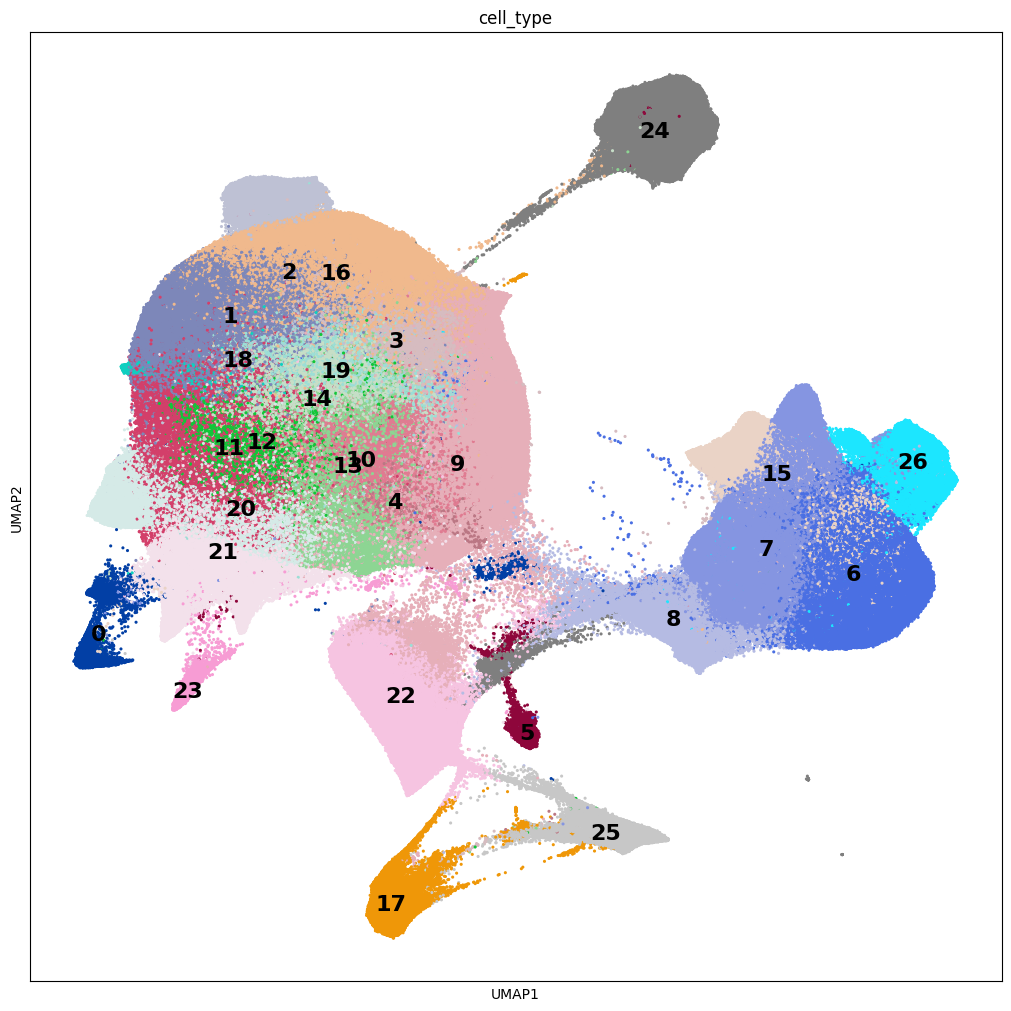

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10), constrained_layout=True)
sc.pl.embedding(
    adata,
    basis="umap",
    color="cell_type",
    legend_loc="on data",
    size=20,
    ax=ax,
    show=False,
    legend_fontsize=16
)

In [ ]:
# adata.write_h5ad(common_data._sc_root / '04scVI_1000hvg_10.h5ad')

In [ ]:
adata = sc.read_h5ad(common_data._sc_root / '04scVI_1000hvg_10.h5ad')

### Total counts per cell

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


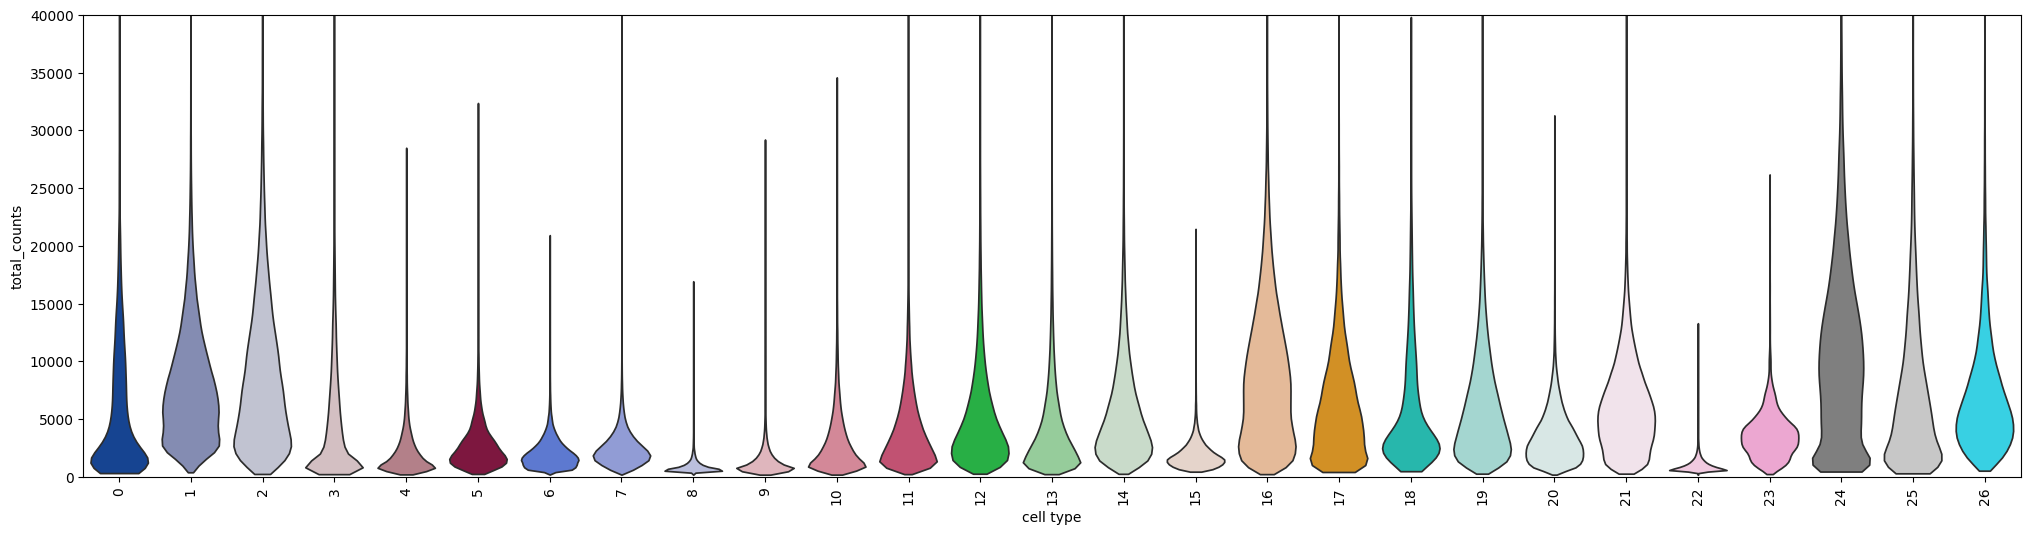

In [3]:
fig, ax = plt.subplots(figsize=(25, 6))
sc.pl.violin(adata, "total_counts", groupby="cell_type", size=0, ax=ax, show=False)
# ax.axhline(500, c="red", lw=1)
ax.set_ylim(0, 40000)
trans = mpl.transforms.Affine2D().translate(6, 0)
for t in ax.get_xticklabels():
    t.set_size(10)
    t.set_rotation(90)
    # t.set_horizontalalignment("right")
    # t.set_transform(t.get_transform() + trans)

### Number of expressed genes in a cell

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


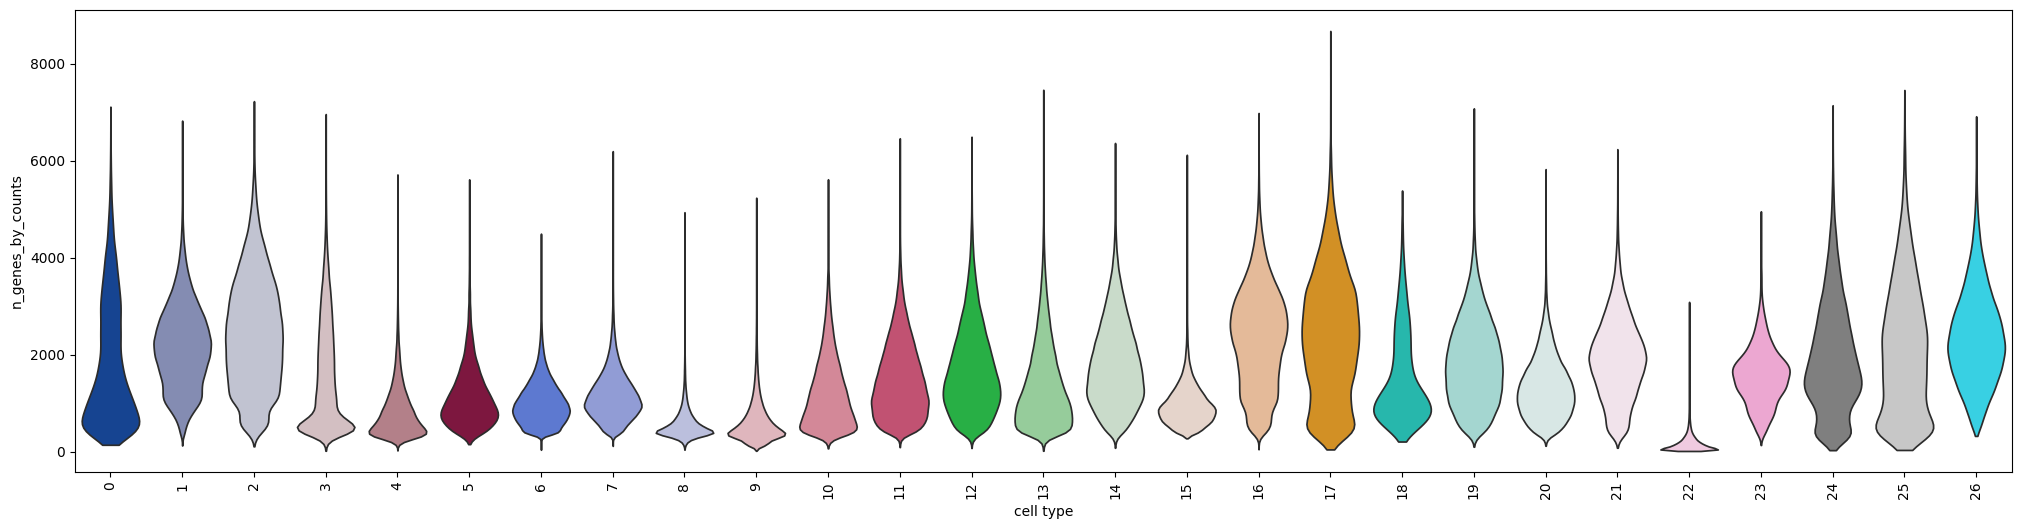

In [4]:
fig, ax = plt.subplots(figsize=(25, 6))
sc.pl.violin(adata, "n_genes_by_counts", groupby="cell_type", size=0, ax=ax, show=False)
trans = mpl.transforms.Affine2D().translate(6, 0)
for t in ax.get_xticklabels():
    t.set_size(10)
    t.set_rotation(90)
    # t.set_horizontalalignment("right")
    # t.set_transform(t.get_transform() + trans)

### Percentage of counts in mitochondrial genes

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


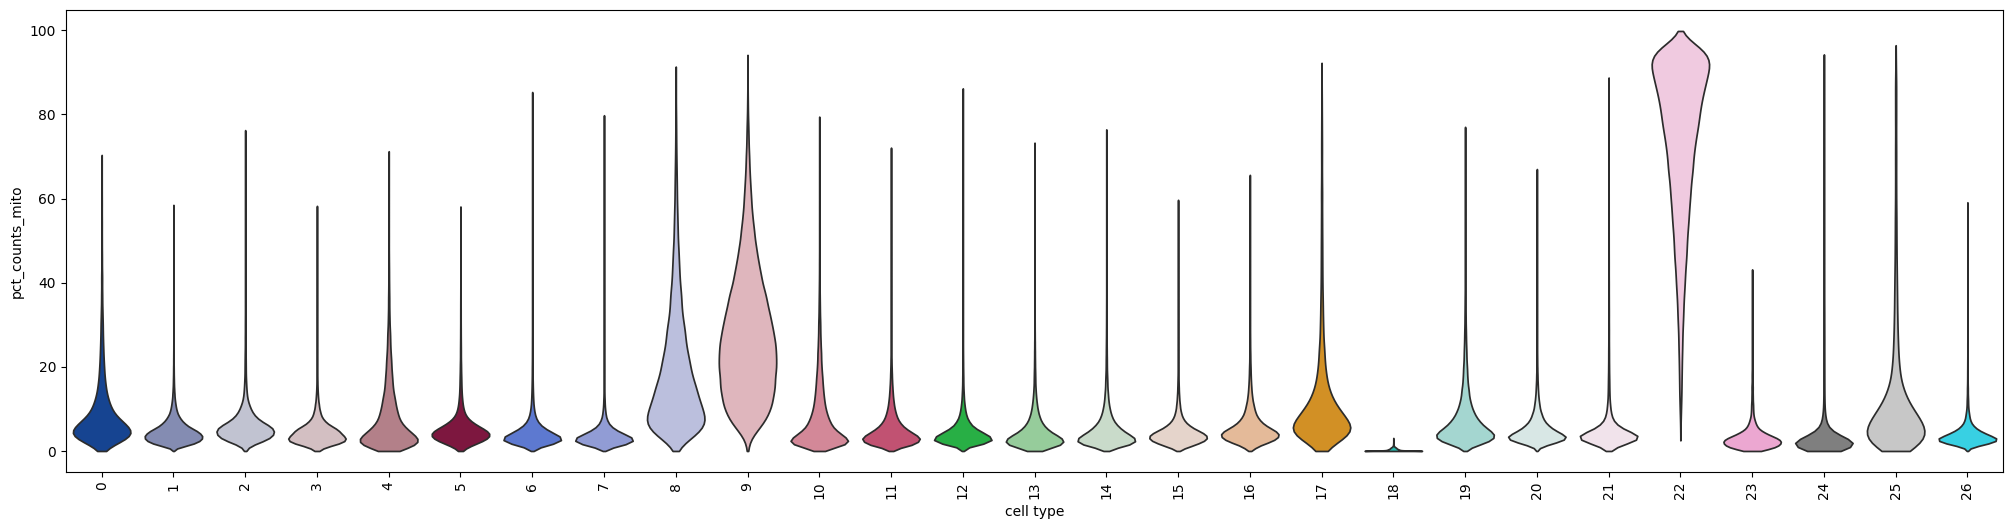

In [5]:
fig, ax = plt.subplots(figsize=(25, 6))
sc.pl.violin(adata, "pct_counts_mito", groupby="cell_type", size=0, ax=ax, show=False)
# ax.axhline(500, c="red", lw=1)
trans = mpl.transforms.Affine2D().translate(6, 0)
for t in ax.get_xticklabels():
    t.set_size(10)
    t.set_rotation(90)
    # t.set_horizontalalignment("right")
    # t.set_transform(t.get_transform() + trans)

Filter out clusters: 8, 9, 22 - high MT and low total counts.

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:748: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


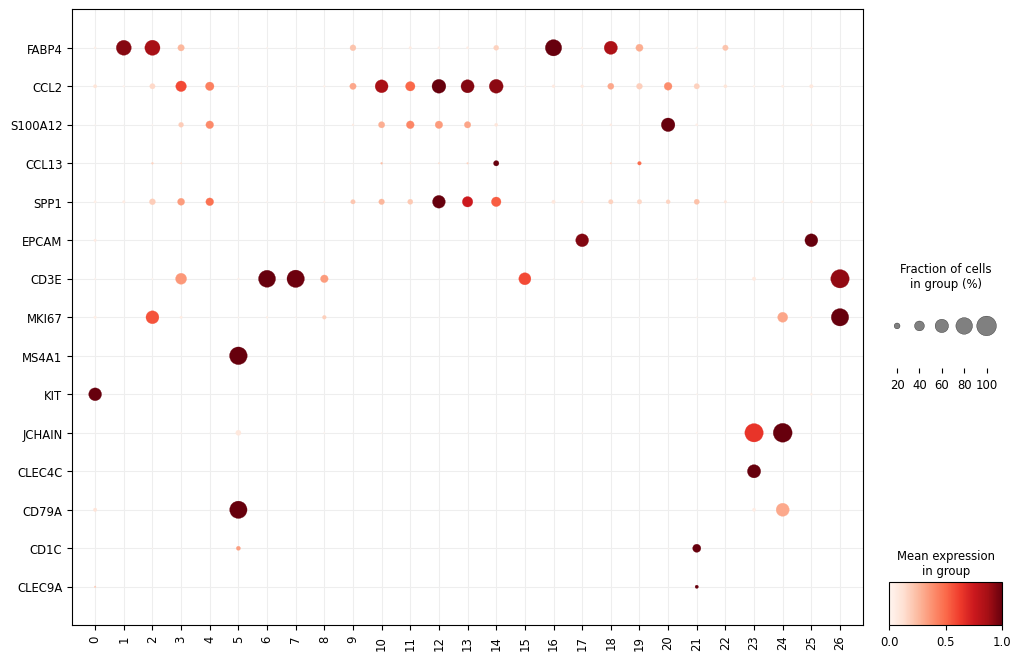

In [6]:
ax = sc.pl.dotplot(
    adata,
    ["FABP4", # TRAM
     "CCL2", # MoAM
     "S100A12", # monocytes
     "CCL13", # perivascular macs
     "SPP1", # profibrotic macs
     "EPCAM", # epithelial
     "CD3E", # T cells
     "MKI67", # proliferating
     "MS4A1", # B cells
     "KIT", # mast
     "JCHAIN", "CLEC4C", # pDC
                "CD79A", # plasma
     "CD1C", # DC2
     "CLEC9A", # DC1
     ],
    groupby="cell_type",
    swap_axes=True,
    figsize=(12, 8),
    standard_scale="var",
    edgecolor=None,
    show=False,
    zorder=2,
    use_raw=True
)
ax["mainplot_ax"].grid(c="#eeeeee", zorder=0)

Doublet clusters: cluster 3 (T cells and macrophages)

In [7]:
adata

AnnData object with n_obs × n_vars = 3017150 × 1000
    obs: 'name', 'library_id', 'individual', 'protocol', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'pct_counts_ribo', 'n_counts', '_scvi_batch', '_scvi_labels', 'cell_type'
    var: 'gene_ids', 'feature_types', 'genome', 'mito', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_colors', 'hvg', 'leiden', 'library_id_colors', 'neighbors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

### What percent of cells have been filtered out for each library?
If sample quality is compromised and most of the cells from this library had been filtered out, then the cell loss can disproportionately affect cell type abundances. In order to avoid this, we should fully remove libraries that have already been largely filtered.

In [8]:
prefiltering = adata.obs.library_id.value_counts()
postfiltering = adata.obs.loc[~adata.obs.cell_type.isin(['3','8','9','22'])].library_id.value_counts()

# Create a dictionary to store the data
data = {
    'library_id': prefiltering.index,
    'prefiltering_counts': prefiltering.reindex(prefiltering.index),
    'postfiltering_counts': postfiltering.reindex(prefiltering.index)
}

# Create a DataFrame
counts_by_library = pd.DataFrame(data)
counts_by_library['pct_filtered'] =  (((counts_by_library.prefiltering_counts - counts_by_library.postfiltering_counts) / counts_by_library.prefiltering_counts) * 100)

In [9]:
counts_by_library

,library_id,prefiltering_counts,postfiltering_counts,pct_filtered
SC327,SC327,30551,4706,84.596249
SC452,SC452,26604,23331,12.302661
SC427,SC427,23507,18396,21.742460
SC277,SC277,22956,18430,19.715978
SC555,SC555,22240,17327,22.090827
...,...,...,...,...
SC482,SC482,1098,876,20.218579
SC383,SC383,965,773,19.896373
SC472,SC472,650,451,30.615385
SC465,SC465,595,454,23.697479


### Plot histogram
In which libraries did we filter out the majority of cells?

<Axes: ylabel='Frequency'>

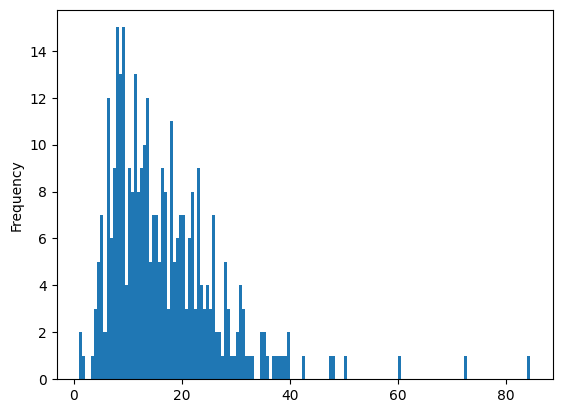

In [10]:
# right side - most of the cells in the library had been filtered out
counts_by_library.pct_filtered.plot.hist(bins=150)

<Axes: xlabel='pct_filtered', ylabel='postfiltering_counts'>

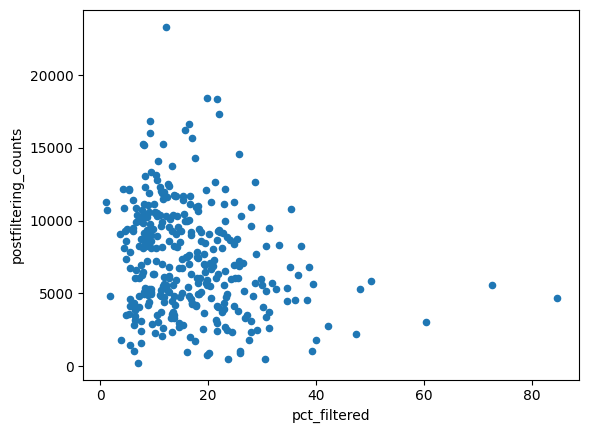

In [11]:
# library level
# x = % kept
# y = number of cells kept
counts_by_library.plot.scatter(x='pct_filtered', y='postfiltering_counts')

In outlier libraries where most of the library had been filtered out, we still retain a decent number of cells (just under 5k). Based on this result, I will not filter out any additional libraries.

### Remove low quality clusters + doublets from object

In [13]:
adata = adata[~adata.obs.cell_type.isin(['3', '8', '9', '22'])]

### Save

In [ ]:
adata.write_h5ad(common_data._sc_root / '04scVI_1000hvg_10-2.h5ad')

In [ ]:
%%time
sc.tl.rank_genes_groups(adata, "cell_type", method="t-test", n_genes=50)

In [ ]:
markers = sc_utils.get_markers(adata, "cell_type")

In [ ]:
markers.cluster = markers.cluster.astype(int)
markers.sort_values(["cluster", "avg_logFC"], ascending=[True, False], inplace=True)

In [ ]:
markers.groupby("cluster").head(5)

Based on markers, violin plots and UMAP:



In [ ]:
# markers.loc[markers.cluster.isin([5, 6])].groupby("cluster").head(20)

In [ ]:
# to_exclude = ["7", "10", "15", "18"]

In [ ]:
# pd.Series(ds.obs_names[~ds.obs.leiden.isin(to_exclude)]).to_csv("../../data-v2/22integration/03to-keep.csv")